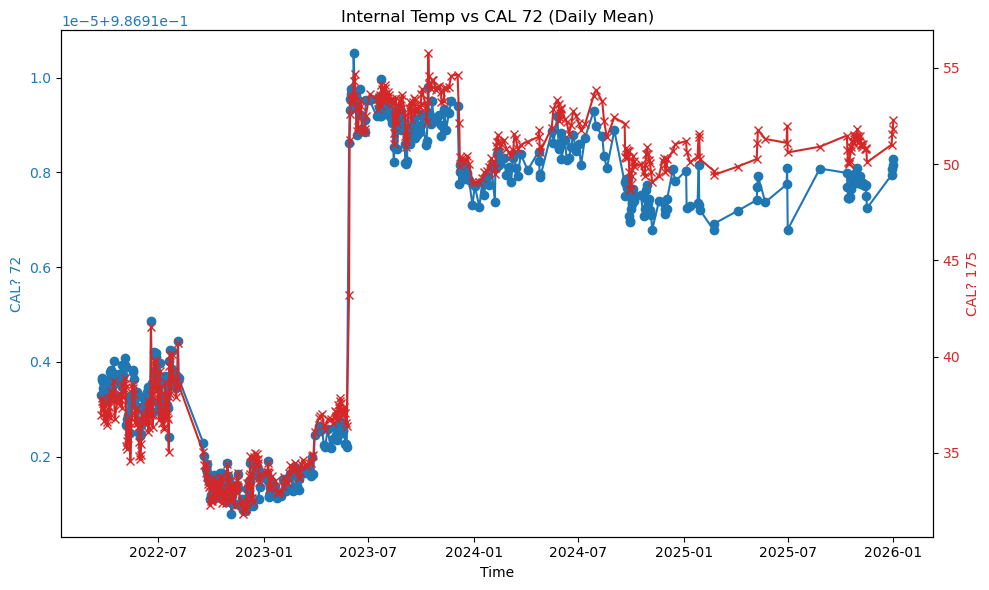

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load data, naming columns and identifying "undefined" as NaN
column_names = ['Time', 'CAL? 72', 'CAL? 175']
df = pd.read_csv('csv/Keysight 3458A internal temp vs CAL 72.csv', na_values="undefined")

# 2. Convert Time (ms) to Datetime and set as index
df['Time'] = pd.to_datetime(df['Time'], unit='ms')
df = df.set_index('Time')

# 3. Clean and merge rows
# Forward fill propagates the last valid sensor reading to the next row
df = df.ffill()
# Backward fill handles cases where the first reading of a sensor might be missing
df = df.bfill()

# 4. Resample to daily means (as in your original script)
df_daily = df.resample('1D').mean().dropna(how="all")

# 5. Round and Export
df_daily = df_daily.round({'CAL? 175': 2, 'CAL? 72': 9})
df_daily.to_csv('out.csv', index=True)

# 6. Plotting
fig, ax1 = plt.subplots(figsize=(10, 6))

color = 'tab:blue'
ax1.set_xlabel('Time')
ax1.set_ylabel('CAL? 72', color=color)
ax1.plot(df_daily.index, df_daily['CAL? 72'], color=color, marker='o')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis
color = 'tab:red'
ax2.set_ylabel('CAL? 175', color=color)
ax2.plot(df_daily.index, df_daily['CAL? 175'], color=color, marker='x')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Internal Temp vs CAL 72 (Daily Mean)')
fig.tight_layout()
plt.savefig('sensor_plot.png')

In [7]:
import pandas as pd

# 1. Define filenames
input_file = 'csv/Keysight 3458A internal temp vs CAL 72.csv'
output_file = 'out.csv'

# 2. Load the data
df = pd.read_csv(input_file, na_values="undefined")

# 3. Process the Time column
df['Time'] = pd.to_datetime(pd.to_numeric(df['Time'], errors='coerce'), unit='ms')
df = df.set_index('Time')

# 4. Merge rows and fill missing data
df = df.ffill().bfill()

# 5. Clean up and aggregate
df_clean = df.resample('1D').mean().dropna(how="all")

# 6. Reorder columns and Round
# Simply pass the list of column names in your preferred order
df_clean = df_clean[['CAL? 175', 'CAL? 72']]
df_clean = df_clean.round({'CAL? 175': 2, 'CAL? 72': 9})

# 7. Export
df_clean.to_csv(output_file, index=True)

print(f"Cleanup complete. Columns reordered. File saved as: {output_file}")

Cleanup complete. Columns reordered. File saved as: out.csv
